In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier


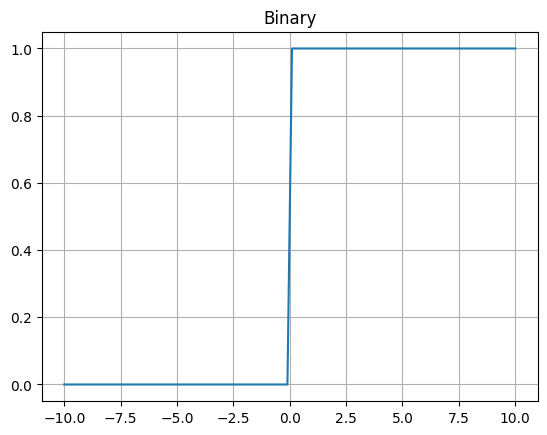

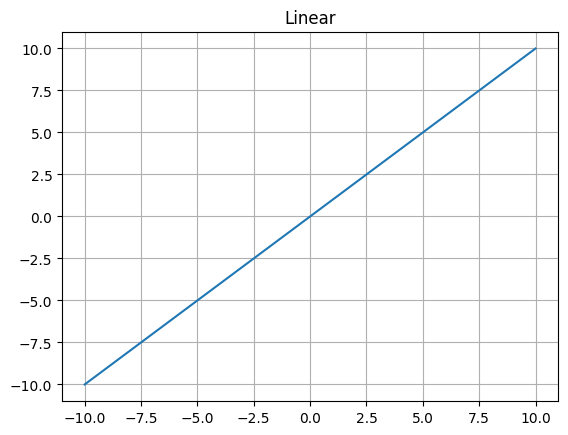

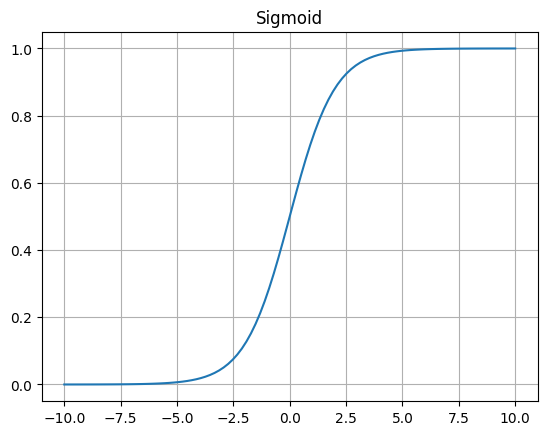

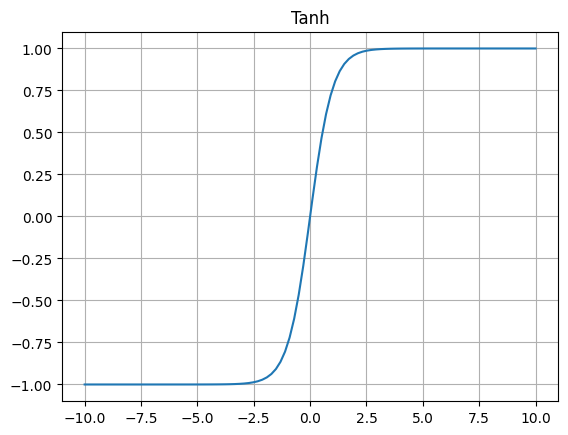

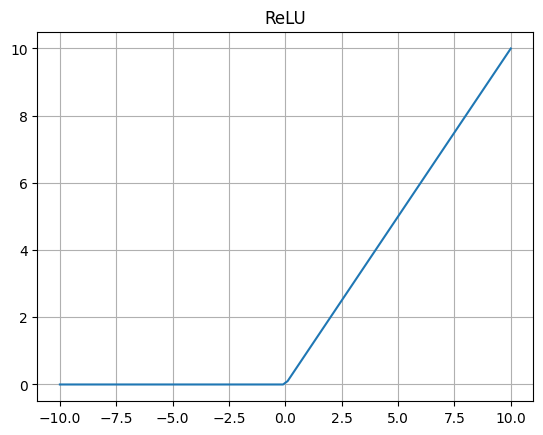

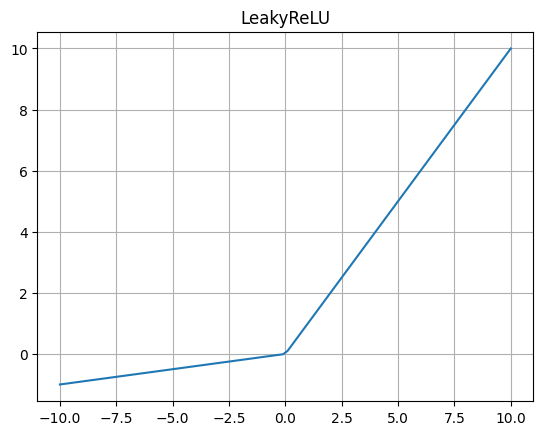

In [2]:
#PART A: Activation Functions

x = np.linspace(-10, 10, 100)

def binary(x): return np.where(x > 0, 1, 0)
def linear(x): return x
def sigmoid(x): return 1 / (1 + np.exp(-x))
def tanh(x): return np.tanh(x)
def relu(x): return np.maximum(0, x)
def leakyrelu(x): return np.where(x > 0, x, 0.1 * x)

functions = {
    "Binary": binary(x),
    "Linear": linear(x),
    "Sigmoid": sigmoid(x),
    "Tanh": tanh(x),
    "ReLU": relu(x),
    "LeakyReLU": leakyrelu(x)
}

for name, y in functions.items():
    plt.figure()
    plt.plot(x, y)
    plt.title(name)
    plt.grid()
    plt.show()

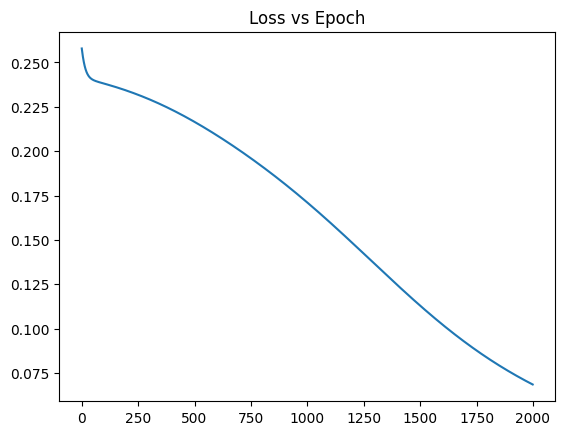

Predictions:
[[0.]
 [1.]
 [1.]
 [0.]]


In [3]:
#PART B: Simple Neural Network (XOR)

X = np.array([[0,0],[0,1],[1,0],[1,1]])
Y = np.array([[0],[1],[1],[0]])

np.random.seed(0)
W1 = np.random.randn(2, 3)
W2 = np.random.randn(3, 1)

lr = 0.1
losses = []

for i in range(2000):   # reduced epochs for exam
    H = sigmoid(np.dot(X, W1))
    O = sigmoid(np.dot(H, W2))

    error = Y - O
    losses.append(np.mean(error**2))

    dO = error * O * (1 - O)
    dH = dO.dot(W2.T) * H * (1 - H)

    W2 += H.T.dot(dO) * lr
    W1 += X.T.dot(dH) * lr

plt.plot(losses)
plt.title("Loss vs Epoch")
plt.show()

print("Predictions:")
print(np.round(O))


 Logistic
Accuracy: 0.8688524590163934
[[21  6]
 [ 2 32]]
              precision    recall  f1-score   support

           0       0.91      0.78      0.84        27
           1       0.84      0.94      0.89        34

    accuracy                           0.87        61
   macro avg       0.88      0.86      0.86        61
weighted avg       0.87      0.87      0.87        61



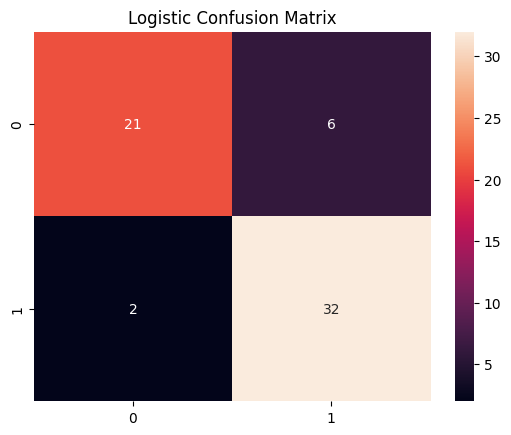


 ANN
Accuracy: 0.8688524590163934
[[21  6]
 [ 2 32]]
              precision    recall  f1-score   support

           0       0.91      0.78      0.84        27
           1       0.84      0.94      0.89        34

    accuracy                           0.87        61
   macro avg       0.88      0.86      0.86        61
weighted avg       0.87      0.87      0.87        61



C:\Users\JINESHA GANDHI\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


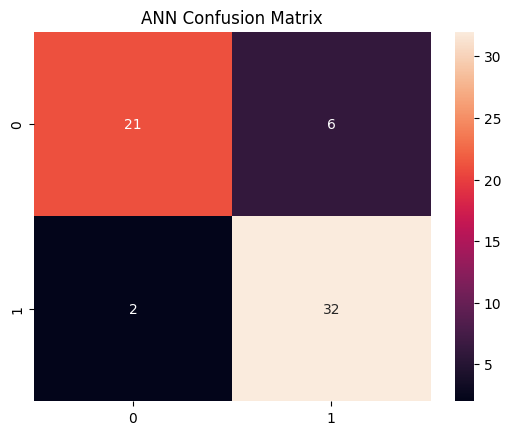

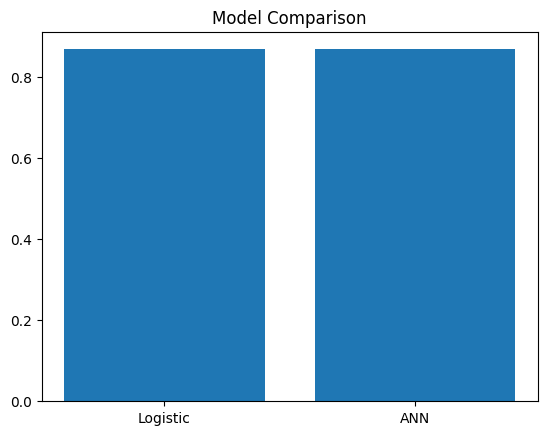

Best Model: Logistic


In [4]:
 
#  PART C: ANN vs ML 

df = pd.read_csv("C:\\Users\\JINESHA GANDHI\\Downloads\\heart.csv")

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "ANN": MLPClassifier(hidden_layer_sizes=(16,8), max_iter=300, random_state=42)
}

acc = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc[name] = accuracy_score(y_test, pred)

    print("\n", name)
    print("Accuracy:", acc[name])
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred))

    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d')
    plt.title(name + " Confusion Matrix")
    plt.show()

plt.bar(acc.keys(), acc.values())
plt.title("Model Comparison")
plt.show()

best = max(acc, key=acc.get)
print("Best Model:", best)
